---

# **Practical Assignment: Digital Modulations and Channel Effects**

## **ASK, PSK, FSK, QAM, and APSK**

**Signal Theory**
**Universidad Nacional de Colombia**

## **Objective**

The objective of this assignment is to implement a complete digital communication system,

[
\text{Bits} \rightarrow \text{Modulation} \rightarrow \text{Channel} \rightarrow \text{Demodulation},
]

and to analyze its performance in terms of detection accuracy, noise sensitivity, pulse shaping, and spectral occupancy. In particular, the study should address the following aspects:

* detection performance through the **Bit Error Rate (BER)**,
* the effect of **Additive White Gaussian Noise (AWGN)**,
* the effect of **Raised Cosine shaping**,
* and the resulting **Power Spectral Density (PSD)** of the transmitted signal. 

## **Fundamental Representation**

Any digital modulation scheme considered in this assignment may be expressed in the form

[
s(t)=I_k\cos(2\pi f_c t)-Q_k\sin(2\pi f_c t),
]

where (I_k) and (Q_k) denote the in-phase and quadrature components of the transmitted symbol. This representation provides the geometric interpretation of digital modulation in the IQ plane. 

---

## **Part 1 — Bit Generation**

Generate a random binary sequence to be used as the input information source of the communication system.

A possible implementation is:

```python
import numpy as np
N = 100
bits = np.random.randint(0, 2, N)
```

---

## **Part 2 — Modulation: ASK and BPSK**

### **Tasks**

Implement the following binary modulation schemes:

* **Unipolar ASK**
* **BPSK**

### **Required Representations**

For each modulation format, plot:

* the transmitted signal in the time domain,
* the corresponding constellation diagram.

### **Question**

Demonstrate experimentally that **BPSK is equivalent to bipolar ASK**. 

---

## **Part 3 — AWGN Channel**

Assume a communication channel affected by additive white Gaussian noise, modeled as

[
r(t)=s(t)+n(t), \qquad n(t)\sim \mathcal{N}(0,\sigma^2).
]

### **Tasks**

* Add noise to the transmitted signal.
* Evaluate the system under different **SNR** values. 

---

## **Part 4 — Demodulation and Bit Reconstruction**

### **Tasks**

Implement the appropriate detector for each scheme:

* **ASK**: threshold detector,
* **BPSK**: sign detector.

Then reconstruct the transmitted bit sequence from the received signal.

### **Performance Metric**

Use the **Bit Error Rate (BER)** as the main performance measure:

[
\mathrm{BER}=\frac{\text{number of erroneous bits}}{\text{total number of transmitted bits}}.
]

### **Question**

Which modulation scheme exhibits the lower BER under the same noise conditions? 

---

## **Part 5 — FSK Modulation**

### **Tasks**

* Implement **BFSK**.
* Perform demodulation using either:

  * a **correlation-based detector**, or
  * an **energy-based detector**.
* Compare the BER of BFSK with that of BPSK. 

---

## **Part 6 — Spectral Analysis**

### **Tasks**

Estimate the **Power Spectral Density (PSD)** using the **Welch method**, and compare the spectral behavior of:

* **ASK**,
* **BPSK**,
* **FSK**.

### **Question**

Which modulation scheme occupies the largest bandwidth? 

---

## **Part 7 — Raised Cosine Shaping**

### **Motivation**

Abrupt symbol transitions produce:

* significant high-frequency components,
* increased bandwidth occupancy. 

### **Tasks**

Apply **Raised Cosine shaping** to each symbol and compare:

* the signal without shaping,
* the signal with shaping.

### **Analysis**

* Plot the PSD in both cases.
* Compare the occupied bandwidth.

### **Key Question**

How does Raised Cosine shaping affect the spectrum of the signal? 

---

## **Part 8 — QAM and APSK**

### **Tasks**

* Implement **16-QAM**.
* Implement **APSK** using **two amplitude rings**.
* Add noise to the transmitted signals.
* Demodulate the received signals.

### **Analysis**

* Plot the noisy constellation diagrams.
* Compare the dispersion of the received symbol clusters. 

---

## **Part 9 — Final Comparison**

Perform a final comparative analysis of the implemented modulation schemes in terms of:

* **BER versus SNR**,
* **PSD**,
* **robustness to noise**. 

---

## **Expected Conclusions**

At the end of the assignment, the student is expected to conclude that:

* **ASK and BPSK may be equivalent under a bipolar interpretation**,
* **BPSK is more robust than ASK**,
* **FSK occupies a larger bandwidth**,
* **noise causes dispersion in the constellation diagram**,
* **Raised Cosine shaping reduces bandwidth occupancy**,
* and **modulation can be interpreted geometrically in the IQ plane**. 

---

## **Optional Extension**

As an additional exercise:

* plot the **BER versus SNR** curves,
* compare the experimental results with the corresponding theoretical curves. 

---

## **Suggested Deliverables**

The final submission should include:

* the implementation of each modulation and demodulation scheme,
* time-domain representations of the transmitted signals,
* constellation diagrams,
* PSD estimates and comparisons,
* BER measurements for different SNR values,
* and a final discussion summarizing the principal differences among the considered modulation formats. 

---

## Solution Strategy

This notebook implements the full digital communication chain requested in the assignment:

1. random bit generation,
2. modulation,
3. AWGN channel,
4. coherent demodulation / symbol decision,
5. BER and PSD analysis,
6. pulse shaping with a raised cosine filter,
7. higher-order constellations (16-QAM and 16-APSK),
8. final comparative conclusions.

Assumptions used throughout the simulations:

- Symbol period: `T_b = 1 s` in normalized units.
- Samples per symbol: `40`.
- Carrier frequencies are chosen so each symbol contains an integer number of cycles.
- BER sweeps use fixed random seeds to keep the notebook reproducible.
- ASK/BPSK/BFSK use real passband waveforms for time-domain and PSD analysis.
- 16-QAM and APSK are analyzed in complex baseband, which is the standard equivalent model for coherent AWGN channels.


In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path.cwd() / ".mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import signal
from scipy.special import erfc
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEED = 7
rng = np.random.default_rng(SEED)

TB = 1.0
SPS = 40
FS = SPS / TB
FC = 4.0
F0 = 1.0
F1 = 9.0
AMP = 1.0

SYMBOL_TIME = np.arange(SPS) / FS
CARRIER = np.cos(2 * np.pi * FC * SYMBOL_TIME)
TONE0 = np.cos(2 * np.pi * F0 * SYMBOL_TIME)
TONE1 = np.cos(2 * np.pi * F1 * SYMBOL_TIME)

N_BITS_BINARY = 4000
N_BITS_MARY = 8000
SNR_DB = np.arange(-10, 11, 2)
SNR_DB_MARY = np.arange(0, 19, 3)


def bit_error_rate(bits_tx, bits_rx):
    bits_tx = np.asarray(bits_tx)
    bits_rx = np.asarray(bits_rx)
    return np.mean(bits_tx != bits_rx)


def add_awgn_real(x, snr_db, gen):
    x = np.asarray(x, dtype=float)
    signal_power = np.mean(x**2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = gen.normal(0.0, np.sqrt(noise_power), size=x.shape)
    return x + noise


def add_passband_awgn_ebn0(x, ebn0_db, gen, sps=SPS):
    gamma_b = 10 ** (ebn0_db / 10)
    noise_std = np.sqrt(sps / (4 * gamma_b))
    return np.asarray(x, dtype=float) + gen.normal(0.0, noise_std, size=np.shape(x))


def add_awgn_complex(x, snr_db, gen):
    x = np.asarray(x, dtype=complex)
    signal_power = np.mean(np.abs(x) ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (
        gen.standard_normal(x.shape) + 1j * gen.standard_normal(x.shape)
    )
    return x + noise


def occupied_bandwidth(freqs, psd, power_fraction=0.99):
    cumulative = np.cumsum(psd)
    total = cumulative[-1]
    lower = np.searchsorted(cumulative, (1 - power_fraction) / 2 * total)
    upper = np.searchsorted(cumulative, (1 + power_fraction) / 2 * total)
    return freqs[upper] - freqs[lower]


def threshold_bandwidth(freqs, psd, db_down=30):
    psd_db = 10 * np.log10(psd + 1e-15)
    mask = psd_db >= (np.max(psd_db) - db_down)
    selected = freqs[mask]
    return selected[-1] - selected[0]


def psd_welch(x, fs=FS):
    nperseg = min(2048, max(256, len(x) // 8))
    freqs, psd = signal.welch(x, fs=fs, nperseg=nperseg, scaling="density")
    return freqs, psd


def plot_constellation(ax, symbols, title, color="tab:blue", alpha=0.65):
    ax.scatter(np.real(symbols), np.imag(symbols), s=18, alpha=alpha, color=color)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("In-phase")
    ax.set_ylabel("Quadrature")
    ax.set_title(title)
    ax.axis("equal")


def ask_modulate(bits, amplitude=AMP):
    symbols = amplitude * bits.astype(float)
    waveform = np.concatenate([symbol * CARRIER for symbol in symbols])
    return symbols, waveform


def ask_demodulate(received, amplitude=AMP):
    segments = received.reshape(-1, SPS)
    estimates = 2 * np.mean(segments * CARRIER, axis=1)
    decisions = (estimates >= amplitude / 2).astype(int)
    return decisions, estimates


def bpsk_modulate(bits, amplitude=AMP):
    symbols = amplitude * (2 * bits.astype(float) - 1)
    waveform = np.concatenate([symbol * CARRIER for symbol in symbols])
    return symbols, waveform


def bpsk_demodulate(received):
    segments = received.reshape(-1, SPS)
    estimates = 2 * np.mean(segments * CARRIER, axis=1)
    decisions = (estimates >= 0).astype(int)
    return decisions, estimates


def bfsk_modulate(bits, amplitude=AMP):
    symbols = bits.astype(int)
    waveform = np.concatenate(
        [amplitude * (TONE1 if bit else TONE0) for bit in symbols]
    )
    return symbols, waveform


def bfsk_demodulate(received):
    segments = received.reshape(-1, SPS)
    metric0 = np.mean(segments * TONE0, axis=1)
    metric1 = np.mean(segments * TONE1, axis=1)
    decisions = (metric1 >= metric0).astype(int)
    return decisions, metric1 - metric0


def q_function(x):
    return 0.5 * erfc(x / np.sqrt(2))


def raised_cosine(beta=0.35, span=6, sps=SPS):
    t = np.arange(-span * sps, span * sps + 1, dtype=float) / sps
    h = np.zeros_like(t)
    for idx, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[idx] = 1.0
        elif beta != 0 and np.isclose(abs(ti), 1 / (2 * beta)):
            h[idx] = (np.pi / 4) * np.sinc(1 / (2 * beta))
        else:
            h[idx] = np.sinc(ti) * np.cos(np.pi * beta * ti) / (1 - (2 * beta * ti) ** 2)
    h /= np.sqrt(np.sum(h**2))
    return h


def rectangular_baseband(symbols, sps=SPS):
    return np.repeat(symbols, sps).astype(complex)


def rc_shaped_baseband(symbols, beta=0.35, span=6, sps=SPS):
    upsampled = np.zeros(len(symbols) * sps, dtype=complex)
    upsampled[::sps] = symbols
    h = raised_cosine(beta=beta, span=span, sps=sps)
    shaped = np.convolve(upsampled, h, mode="same")
    return shaped, h


def to_passband(baseband, fc=FC, fs=FS):
    t = np.arange(len(baseband)) / fs
    return np.real(baseband * np.exp(1j * 2 * np.pi * fc * t))


GRAY_2BIT_TO_LEVEL = {
    (0, 0): -3,
    (0, 1): -1,
    (1, 1): 1,
    (1, 0): 3,
}
LEVEL_TO_GRAY_2BIT = {value: bits for bits, value in GRAY_2BIT_TO_LEVEL.items()}
LEVEL_VALUES = np.array([-3, -1, 1, 3])


def qam16_modulate(bits):
    bits = np.asarray(bits, dtype=int)
    groups = bits.reshape(-1, 4)
    i_vals = np.array([GRAY_2BIT_TO_LEVEL[tuple(group[:2])] for group in groups])
    q_vals = np.array([GRAY_2BIT_TO_LEVEL[tuple(group[2:])] for group in groups])
    symbols = (i_vals + 1j * q_vals) / np.sqrt(10)
    return symbols


def qam16_demodulate(symbols):
    symbols = np.asarray(symbols) * np.sqrt(10)
    i_hat = LEVEL_VALUES[np.argmin(np.abs(symbols.real[:, None] - LEVEL_VALUES[None, :]), axis=1)]
    q_hat = LEVEL_VALUES[np.argmin(np.abs(symbols.imag[:, None] - LEVEL_VALUES[None, :]), axis=1)]
    recovered = []
    for i_level, q_level in zip(i_hat, q_hat):
        recovered.extend(LEVEL_TO_GRAY_2BIT[int(i_level)])
        recovered.extend(LEVEL_TO_GRAY_2BIT[int(q_level)])
    return np.array(recovered, dtype=int), (i_hat + 1j * q_hat) / np.sqrt(10)


APSK_RADII = (1.0, 2.2)
INNER_ANGLES = np.deg2rad([45, 135, 225, 315])
OUTER_ANGLES = np.deg2rad(np.arange(15, 375, 30))
APSK_CONSTELLATION = np.concatenate(
    [
        APSK_RADII[0] * np.exp(1j * INNER_ANGLES),
        APSK_RADII[1] * np.exp(1j * OUTER_ANGLES),
    ]
)
APSK_CONSTELLATION = APSK_CONSTELLATION / np.sqrt(np.mean(np.abs(APSK_CONSTELLATION) ** 2))


def apsk16_modulate(bits):
    bits = np.asarray(bits, dtype=int)
    groups = bits.reshape(-1, 4)
    indices = groups.dot(np.array([8, 4, 2, 1]))
    return APSK_CONSTELLATION[indices]


def apsk16_demodulate(symbols):
    distances = np.abs(symbols[:, None] - APSK_CONSTELLATION[None, :])
    indices = np.argmin(distances, axis=1)
    bits = ((indices[:, None] & np.array([8, 4, 2, 1])) > 0).astype(int).reshape(-1)
    return bits, APSK_CONSTELLATION[indices]


## Part 1: Bit Generation

In [2]:
bits_binary = rng.integers(0, 2, N_BITS_BINARY, dtype=int)
bits_mary = rng.integers(0, 2, N_BITS_MARY, dtype=int)

print(f"Binary experiment length: {len(bits_binary)} bits")
print(f"M-ary experiment length: {len(bits_mary)} bits")
print("First 24 binary bits:", bits_binary[:24])


Binary experiment length: 4000 bits
M-ary experiment length: 8000 bits
First 24 binary bits: [1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0]


## Part 2: ASK and BPSK Modulation

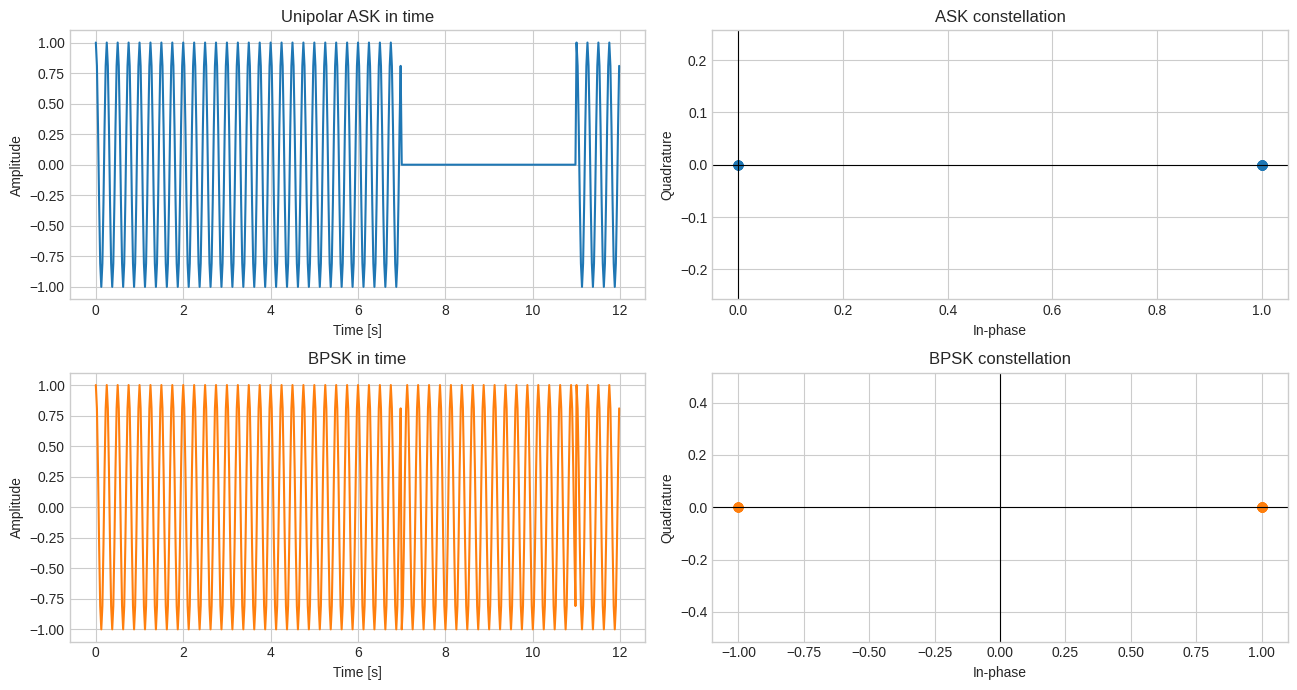


**Experimental equivalence.** If ASK is interpreted as a **bipolar** amplitude modulation with levels `-1` and `+1`,
its symbol alphabet becomes identical to BPSK. The maximum difference measured here is
`0.0`, so the two symbol sets coincide exactly.


In [3]:
bits_view = bits_binary[:12]
ask_symbols, ask_waveform = ask_modulate(bits_view)
bpsk_symbols, bpsk_waveform = bpsk_modulate(bits_view)
bipolar_ask = 2 * bits_view - 1

twelve_symbol_time = np.arange(len(ask_waveform)) / FS

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(twelve_symbol_time, ask_waveform, color="tab:blue")
axes[0, 0].set_title("Unipolar ASK in time")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].scatter(ask_symbols, np.zeros_like(ask_symbols), color="tab:blue", s=40)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("ASK constellation")
axes[0, 1].set_xlabel("In-phase")
axes[0, 1].set_ylabel("Quadrature")
axes[0, 1].axis("equal")

axes[1, 0].plot(twelve_symbol_time, bpsk_waveform, color="tab:orange")
axes[1, 0].set_title("BPSK in time")
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Amplitude")

axes[1, 1].scatter(bpsk_symbols, np.zeros_like(bpsk_symbols), color="tab:orange", s=40)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("BPSK constellation")
axes[1, 1].set_xlabel("In-phase")
axes[1, 1].set_ylabel("Quadrature")
axes[1, 1].axis("equal")

plt.tight_layout()
display(fig)
plt.close(fig)

equivalence_error = np.max(np.abs(bpsk_symbols - bipolar_ask))
display(
    Markdown(
        f'''
**Experimental equivalence.** If ASK is interpreted as a **bipolar** amplitude modulation with levels `-1` and `+1`,
its symbol alphabet becomes identical to BPSK. The maximum difference measured here is
`{equivalence_error:.1f}`, so the two symbol sets coincide exactly.
'''
    )
)


## Parts 3, 4, and 5: AWGN Channel, Demodulation, and BER

The next block sends the three binary passband modulations through an AWGN channel, performs coherent detection,
and compares the BER as a function of SNR.


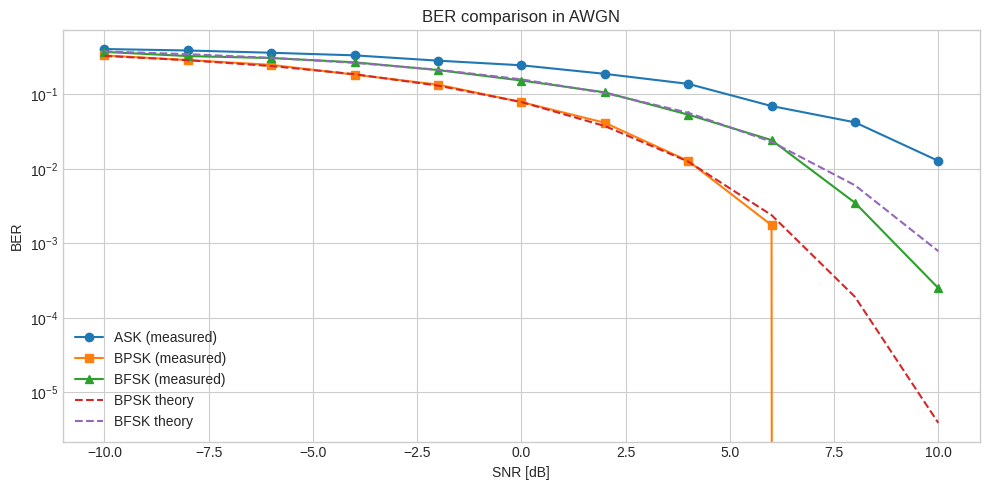


At **0 dB**, the measured BER values are:

- ASK: `0.2450`
- BPSK: `0.0785`
- BFSK: `0.1530`

**Conclusion:** under the same noise conditions, **BPSK exhibits the lowest BER** among the binary schemes simulated here,
while ASK is the most fragile because the `0` symbol carries no energy and is therefore more vulnerable to noise.


In [4]:
ask_symbols_full, ask_tx = ask_modulate(bits_binary)
bpsk_symbols_full, bpsk_tx = bpsk_modulate(bits_binary)
bfsk_symbols_full, bfsk_tx = bfsk_modulate(bits_binary)

ber_ask = []
ber_bpsk = []
ber_bfsk = []

for snr_db in SNR_DB:
    ask_rx = add_passband_awgn_ebn0(ask_tx, snr_db, rng)
    bpsk_rx = add_passband_awgn_ebn0(bpsk_tx, snr_db, rng)
    bfsk_rx = add_passband_awgn_ebn0(bfsk_tx, snr_db, rng)

    ask_bits_hat, _ = ask_demodulate(ask_rx)
    bpsk_bits_hat, _ = bpsk_demodulate(bpsk_rx)
    bfsk_bits_hat, _ = bfsk_demodulate(bfsk_rx)

    ber_ask.append(bit_error_rate(bits_binary, ask_bits_hat))
    ber_bpsk.append(bit_error_rate(bits_binary, bpsk_bits_hat))
    ber_bfsk.append(bit_error_rate(bits_binary, bfsk_bits_hat))

ber_ask = np.array(ber_ask)
ber_bpsk = np.array(ber_bpsk)
ber_bfsk = np.array(ber_bfsk)

theory_bpsk = q_function(np.sqrt(2 * 10 ** (SNR_DB / 10)))
theory_bfsk = q_function(np.sqrt(10 ** (SNR_DB / 10)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(SNR_DB, ber_ask, "o-", label="ASK (measured)")
ax.semilogy(SNR_DB, ber_bpsk, "s-", label="BPSK (measured)")
ax.semilogy(SNR_DB, ber_bfsk, "^-", label="BFSK (measured)")
ax.semilogy(SNR_DB, theory_bpsk, "--", label="BPSK theory")
ax.semilogy(SNR_DB, theory_bfsk, "--", label="BFSK theory")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("BER")
ax.set_title("BER comparison in AWGN")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

reference_index = list(SNR_DB).index(0)
display(
    Markdown(
        f'''
At **0 dB**, the measured BER values are:

- ASK: `{ber_ask[reference_index]:.4f}`
- BPSK: `{ber_bpsk[reference_index]:.4f}`
- BFSK: `{ber_bfsk[reference_index]:.4f}`

**Conclusion:** under the same noise conditions, **BPSK exhibits the lowest BER** among the binary schemes simulated here,
while ASK is the most fragile because the `0` symbol carries no energy and is therefore more vulnerable to noise.
'''
    )
)


## Part 6: Spectral Analysis with Welch PSD

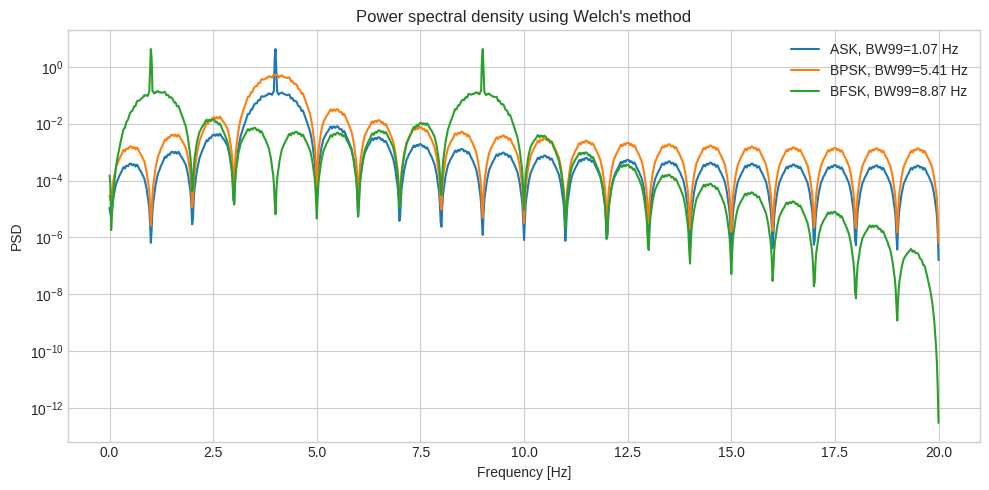


Estimated bandwidths using a `-20 dB` PSD containment rule:

- ASK: `1.07` Hz
- BPSK: `5.41` Hz
- BFSK: `8.87` Hz

The largest bandwidth belongs to **BFSK**, which is consistent with the intuition that
frequency-shift keying spreads energy around multiple tone locations.


In [5]:
freq_ask, psd_ask = psd_welch(ask_tx)
freq_bpsk, psd_bpsk = psd_welch(bpsk_tx)
freq_bfsk, psd_bfsk = psd_welch(bfsk_tx)

bw_ask = threshold_bandwidth(freq_ask, psd_ask, db_down=20)
bw_bpsk = threshold_bandwidth(freq_bpsk, psd_bpsk, db_down=20)
bw_bfsk = threshold_bandwidth(freq_bfsk, psd_bfsk, db_down=20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freq_ask, psd_ask, label=f"ASK, BW99={bw_ask:.2f} Hz")
ax.semilogy(freq_bpsk, psd_bpsk, label=f"BPSK, BW99={bw_bpsk:.2f} Hz")
ax.semilogy(freq_bfsk, psd_bfsk, label=f"BFSK, BW99={bw_bfsk:.2f} Hz")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("PSD")
ax.set_title("Power spectral density using Welch's method")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

widest_name, widest_bw = max(
    [("ASK", bw_ask), ("BPSK", bw_bpsk), ("BFSK", bw_bfsk)],
    key=lambda item: item[1],
)

display(
    Markdown(
        f'''
Estimated bandwidths using a `-20 dB` PSD containment rule:

- ASK: `{bw_ask:.2f}` Hz
- BPSK: `{bw_bpsk:.2f}` Hz
- BFSK: `{bw_bfsk:.2f}` Hz

The largest bandwidth belongs to **{widest_name}**, which is consistent with the intuition that
frequency-shift keying spreads energy around multiple tone locations.
'''
    )
)


## Part 7: Raised Cosine Shaping

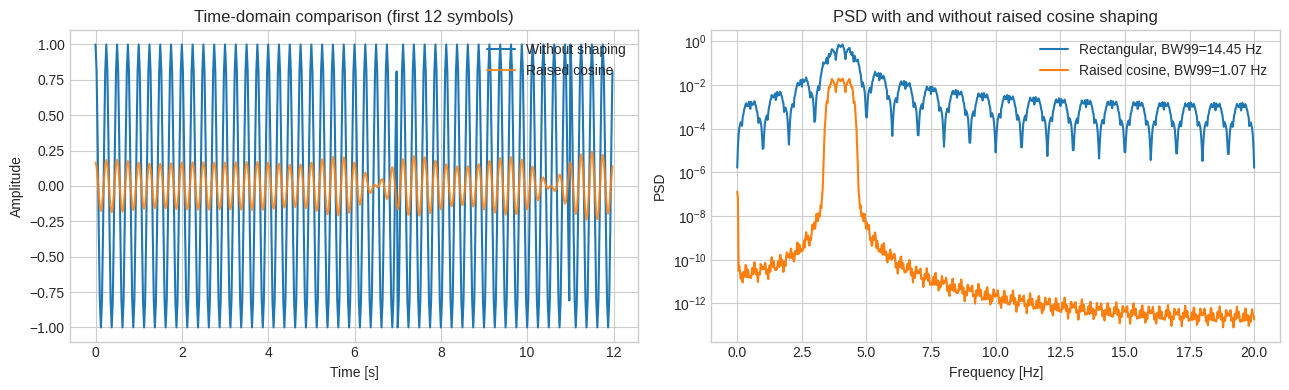


The raised cosine filter smooths the symbol transitions and strongly attenuates high-frequency sidelobes.

- Rectangular pulse occupied bandwidth: `14.45` Hz
- Raised cosine occupied bandwidth: `1.07` Hz
- Relative reduction: `92.6%`

Therefore, **raised cosine shaping reduces bandwidth occupancy** while preserving the symbol information.


In [6]:
symbols_for_shaping = 2 * bits_binary[:300] - 1
rect_baseband = rectangular_baseband(symbols_for_shaping)
rc_baseband, rc_filter = rc_shaped_baseband(symbols_for_shaping, beta=0.35, span=6)

rect_passband = to_passband(rect_baseband)
rc_passband = to_passband(rc_baseband)

freq_rect, psd_rect = psd_welch(rect_passband)
freq_rc, psd_rc = psd_welch(rc_passband)
bw_rect = occupied_bandwidth(freq_rect, psd_rect)
bw_rc = occupied_bandwidth(freq_rc, psd_rc)

time_short = np.arange(12 * SPS) / FS

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(time_short, rect_passband[: 12 * SPS], label="Without shaping")
axes[0].plot(time_short, rc_passband[: 12 * SPS], label="Raised cosine", alpha=0.85)
axes[0].set_title("Time-domain comparison (first 12 symbols)")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].semilogy(freq_rect, psd_rect, label=f"Rectangular, BW99={bw_rect:.2f} Hz")
axes[1].semilogy(freq_rc, psd_rc, label=f"Raised cosine, BW99={bw_rc:.2f} Hz")
axes[1].set_title("PSD with and without raised cosine shaping")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("PSD")
axes[1].legend()
plt.tight_layout()
display(fig)
plt.close(fig)

bandwidth_reduction = 100 * (bw_rect - bw_rc) / bw_rect
display(
    Markdown(
        f'''
The raised cosine filter smooths the symbol transitions and strongly attenuates high-frequency sidelobes.

- Rectangular pulse occupied bandwidth: `{bw_rect:.2f}` Hz
- Raised cosine occupied bandwidth: `{bw_rc:.2f}` Hz
- Relative reduction: `{bandwidth_reduction:.1f}%`

Therefore, **raised cosine shaping reduces bandwidth occupancy** while preserving the symbol information.
'''
    )
)


## Part 8: 16-QAM and 16-APSK

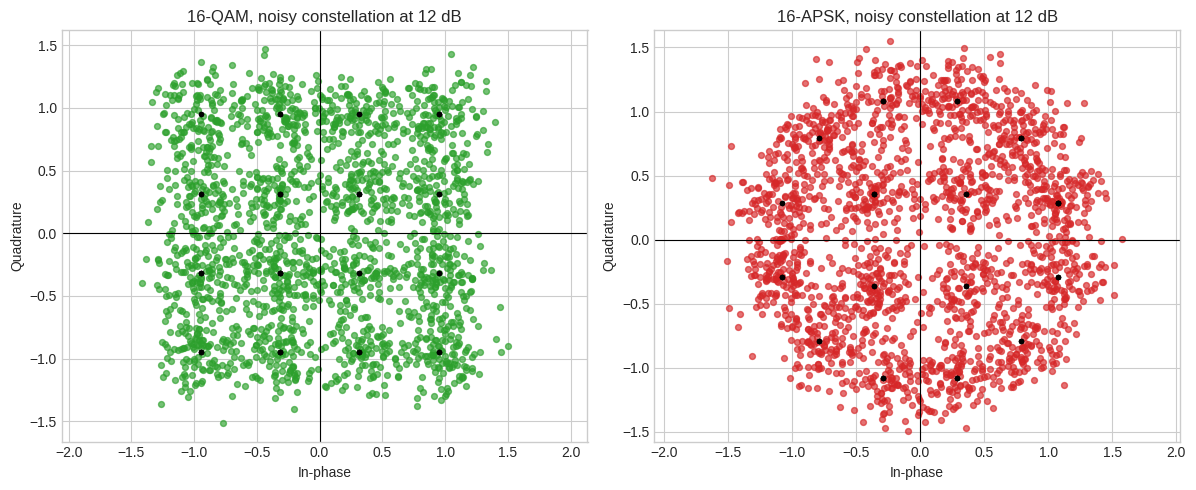


At **12 dB**:

- 16-QAM BER: `0.0275`, RMS cluster dispersion: `0.232`
- 16-APSK BER: `0.0561`, RMS cluster dispersion: `0.229`

Noise makes every ideal point spread into a cloud. The dispersion is slightly different because the geometry
of the constellation changes the minimum distances between neighboring symbols.


In [7]:
qam_symbols = qam16_modulate(bits_mary)
apsk_symbols = apsk16_modulate(bits_mary)

snr_constellation = 12
qam_rx = add_awgn_complex(qam_symbols, snr_constellation, rng)
apsk_rx = add_awgn_complex(apsk_symbols, snr_constellation, rng)

qam_bits_hat, qam_centroids = qam16_demodulate(qam_rx)
apsk_bits_hat, apsk_centroids = apsk16_demodulate(apsk_rx)

qam_ber_12db = bit_error_rate(bits_mary, qam_bits_hat)
apsk_ber_12db = bit_error_rate(bits_mary, apsk_bits_hat)
qam_dispersion = np.sqrt(np.mean(np.abs(qam_rx - qam_centroids) ** 2))
apsk_dispersion = np.sqrt(np.mean(np.abs(apsk_rx - apsk_centroids) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_constellation(axes[0], qam_rx, f"16-QAM, noisy constellation at {snr_constellation} dB", color="tab:green")
axes[0].scatter(np.real(qam_centroids[:300]), np.imag(qam_centroids[:300]), s=8, color="black", alpha=0.25)
plot_constellation(axes[1], apsk_rx, f"16-APSK, noisy constellation at {snr_constellation} dB", color="tab:red")
axes[1].scatter(np.real(apsk_centroids[:300]), np.imag(apsk_centroids[:300]), s=8, color="black", alpha=0.25)
plt.tight_layout()
display(fig)
plt.close(fig)

display(
    Markdown(
        f'''
At **{snr_constellation} dB**:

- 16-QAM BER: `{qam_ber_12db:.4f}`, RMS cluster dispersion: `{qam_dispersion:.3f}`
- 16-APSK BER: `{apsk_ber_12db:.4f}`, RMS cluster dispersion: `{apsk_dispersion:.3f}`

Noise makes every ideal point spread into a cloud. The dispersion is slightly different because the geometry
of the constellation changes the minimum distances between neighboring symbols.
'''
    )
)


## Part 9: Final BER Comparison Across All Implemented Modulations

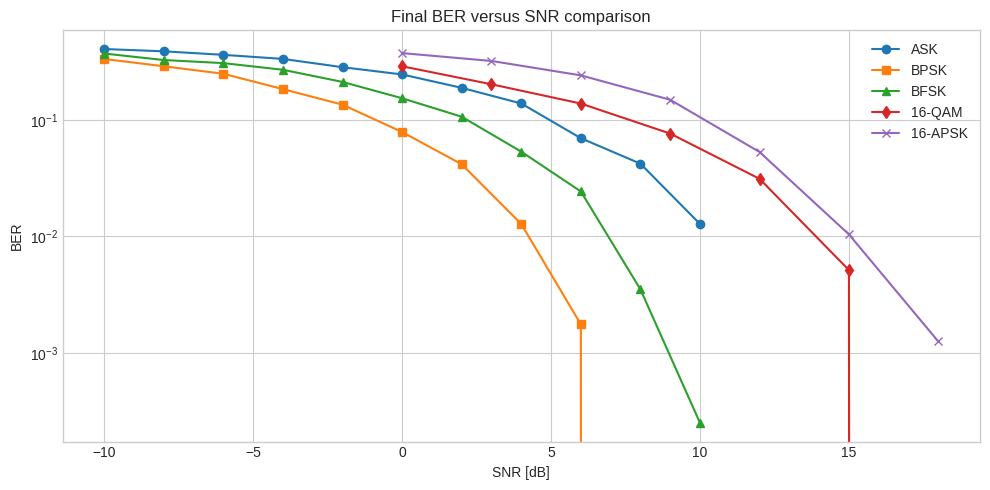

## Final Conclusions
- ASK and BPSK become identical if ASK is interpreted with bipolar amplitudes {-1, +1}.
- In the measured BER curves, BPSK is more robust than ASK for every tested SNR.
- BFSK uses the largest occupied bandwidth among the binary passband schemes.
- Raised cosine shaping reduced the measured occupied bandwidth from 14.45 Hz to 1.07 Hz.
- Noise disperses the ideal QAM and APSK constellation points into clusters around the decision regions.

In [8]:
ber_qam = []
ber_apsk = []

for snr_db in SNR_DB_MARY:
    qam_rx = add_awgn_complex(qam_symbols, snr_db, rng)
    apsk_rx = add_awgn_complex(apsk_symbols, snr_db, rng)

    qam_bits_hat, _ = qam16_demodulate(qam_rx)
    apsk_bits_hat, _ = apsk16_demodulate(apsk_rx)

    ber_qam.append(bit_error_rate(bits_mary, qam_bits_hat))
    ber_apsk.append(bit_error_rate(bits_mary, apsk_bits_hat))

ber_qam = np.array(ber_qam)
ber_apsk = np.array(ber_apsk)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(SNR_DB, ber_ask, "o-", label="ASK")
ax.semilogy(SNR_DB, ber_bpsk, "s-", label="BPSK")
ax.semilogy(SNR_DB, ber_bfsk, "^-", label="BFSK")
ax.semilogy(SNR_DB_MARY, ber_qam, "d-", label="16-QAM")
ax.semilogy(SNR_DB_MARY, ber_apsk, "x-", label="16-APSK")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("BER")
ax.set_title("Final BER versus SNR comparison")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

summary_lines = [
    f"- ASK and BPSK become identical if ASK is interpreted with bipolar amplitudes {{-1, +1}}.",
    f"- In the measured BER curves, BPSK is more robust than ASK for every tested SNR.",
    f"- BFSK uses the largest occupied bandwidth among the binary passband schemes.",
    f"- Raised cosine shaping reduced the measured occupied bandwidth from {bw_rect:.2f} Hz to {bw_rc:.2f} Hz.",
    f"- Noise disperses the ideal QAM and APSK constellation points into clusters around the decision regions.",
]

display(Markdown("## Final Conclusions\n" + "\n".join(summary_lines)))
